<a href="https://colab.research.google.com/github/munizgui/CP2_SEM2_SERS/blob/main/1CCA_ML_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exemplo de treinamento e avaliação de um modelo preditivo de classificação

In [ ]:
# Preparação do ambiente
import pandas as pd

# Ferramentas para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas de Modelagem (utilizar 3 algoritmos do sklearn)

# Separação de dados de treinamento e teste
from sklearn.model_selection import train_test_split

# Algoritmos para classificação
# Regressão Logística
from sklearn.linear_model import LogisticRegression

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Decision Tree
from sklearn.tree  import DecisionTreeClassifier

# Avaliação dos modelos
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
#

#Carga dos dados

In [ ]:
dados =pd.read_csv('Data_for_UCI_named.csv')

# Análise Exploratória

In [ ]:
dados.head()
dados.info()
dados.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [ ]:
# Estatística de colunas categóricas
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [ ]:
# Lista das categorias da coluna alvo
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [ ]:
# Contagem das categorias da coluna 'stabf' (coluna alvo ---> target)
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [ ]:
# Definição de dados de entrada (Features ou Variáveis Independentes)
# e dados de saída (Targer ou Variável Dependene)
# X (maiúsculo) ---> entrada
# y (minúsculo) ---> saída

In [ ]:
X = dados.drop(columns=['stab','stabf'])
y = dados['stabf']

In [ ]:
y

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable
...,...
9995,unstable
9996,stable
9997,stable
9998,unstable


# Separação de dados de treinamento e teste

X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
2694,6.255995,2.542401,7.024714,9.476518,3.529888,-1.224881,-0.688228,-1.616780,0.568221,0.618403,0.685739,0.660088
5140,5.070581,5.490253,8.075688,0.761075,4.220888,-1.280596,-1.902185,-1.038107,0.443515,0.097244,0.916955,0.129254
2568,1.220072,8.804028,3.874283,8.433949,3.614027,-1.039236,-0.953566,-1.621224,0.908353,0.923594,0.238881,0.660156
3671,7.498402,6.697603,8.798626,2.126236,3.134585,-1.581906,-0.589386,-0.963293,0.260826,0.899003,0.964752,0.600598
7427,7.074006,1.337511,6.100756,7.759156,2.526922,-0.922540,-0.632600,-0.971782,0.984580,0.716082,0.836928,0.165162
...,...,...,...,...,...,...,...,...,...,...,...,...
2895,9.504984,5.265415,2.029617,8.026334,3.449756,-0.922754,-1.526305,-1.000696,0.191864,0.611297,0.080008,0.350312
7813,8.035818,4.632548,1.177810,1.204950,4.093208,-1.568218,-0.819966,-1.705024,0.223384,0.317770,0.726623,0.441620
905,7.052560,3.264057,1.405949,4.497549,3.741358,-0.629026,-1.407945,-1.704387,0.868306,0.605566,0.100591,0.747320
5192,5.085242,1.790031,2.486392,2.848192,3.159670,-0.892898,-1.025461,-1.241311,0.473917,0.418512,0.326253,0.982488


Avaliação do Modelo de Regressão Logística:

Acurácia: 0.8040
Precisão (Stable): 0.7395
Recall (Stable): 0.6938
F1-Score (Stable): 0.7159

Matriz de Confusão:
 [[1114  174]
 [ 218  494]]


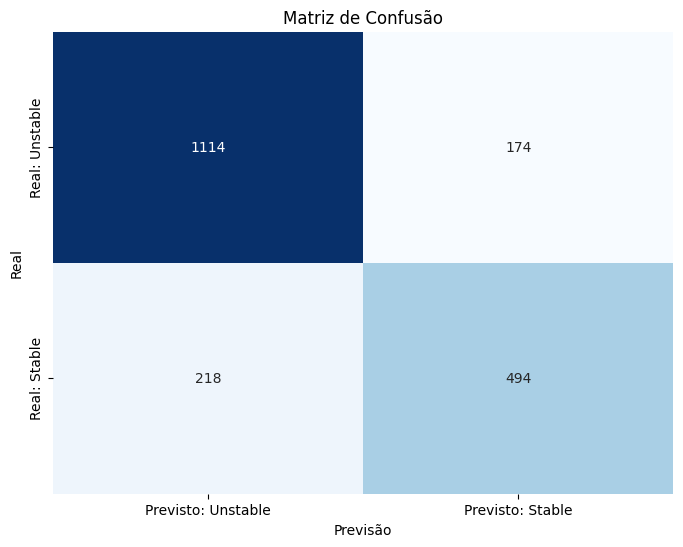


Relatório de Classificação:

              precision    recall  f1-score   support

      stable       0.74      0.69      0.72       712
    unstable       0.84      0.86      0.85      1288

    accuracy                           0.80      2000
   macro avg       0.79      0.78      0.78      2000
weighted avg       0.80      0.80      0.80      2000



In [ ]:
print("Avaliação do Modelo de Regressão Logística:\n")

# Accuracy
accuracy = accuracy_score(y_test, y_predict)
print(f"Acurácia: {accuracy:.4f}")

# Precision (assuming 'stable' as positive class for binary metrics)
precision = precision_score(y_test, y_predict, pos_label='stable')
print(f"Precisão (Stable): {precision:.4f}")

# Recall (assuming 'stable' as positive class for binary metrics)
recall = recall_score(y_test, y_predict, pos_label='stable')
print(f"Recall (Stable): {recall:.4f}")

# F1-Score (assuming 'stable' as positive class for binary metrics)
f1 = f1_score(y_test, y_predict, pos_label='stable')
print(f"F1-Score (Stable): {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_predict, labels=['unstable', 'stable'])
print("\nMatriz de Confusão:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Previsto: Unstable', 'Previsto: Stable'],
            yticklabels=['Real: Unstable', 'Real: Stable'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# Classification Report
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_predict))

In [ ]:
# Instanciando o primeiro (LogisticRegression)
modelo_LR = LogisticRegression()
modelo_LR.fit(X_train, y_train)


LogisticRegression()

In [ ]:
# Geração de previsões
y_predict = modelo_LR.predict(X_test)
y_predict

array(['unstable', 'unstable', 'stable', ..., 'unstable', 'unstable',
       'unstable'], dtype=object)

In [ ]:
# Avaliação do modelo